In [2]:
from __future__ import print_function, unicode_literals, absolute_import, division
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from tifffile import imread
from csbdeep.utils import Path, download_and_extract_zip_file, plot_some
from csbdeep.io import save_tiff_imagej_compatible
from csbdeep.models import CARE
import h5py
import os
from lazy5.inspect import get_attrs_dset
import numpy as np
import matplotlib.pyplot as plt
from utils.datagen import create_spend_patches, norm_percentiles,create_spend_dataset_enhanced
from csbdeep.utils import plot_some

I0000 00:00:1758520599.008347   77912 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1758520599.469190   77912 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1758520601.261923   77912 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
DATA_FOLDER = "./data"
filename = "glycerol_bcars_test.h5"
f = h5py.File(os.path.join(DATA_FOLDER,filename), 'r')
# Access the group
preprocessed_group = f['preprocessed_images']

# Print the names of items within the group
print("Items within the 'preprocessed_images' group:")
for key in preprocessed_group.keys():
    print(key)
# Access the 'medfilter_ratio' dataset within the 'preprocessed_images' group
raw_ratio = f['preprocessed_images/medfilter_ratio']

# Print the shape of the extracted dataset
print("Shape of 'medfilter_ratio' dataset:", raw_ratio.shape)
attrs = get_attrs_dset(f, 'preprocessed_images/medfilter_ratio')

Items within the 'preprocessed_images' group:
medfilter_dark
medfilter_nrb_for_ratio
medfilter_ratio
Shape of 'medfilter_ratio' dataset: (120, 500, 2304)


In [4]:
#Get the wavenumber axis from the attributes
coeffs = attrs['Calib.a_vec']
attrs['Calib.n_pix']= 2304
n_pix = 2304
ctr = attrs['Calib.ctr_wl0']
probe = attrs['Calib.probe']
probe *= 1e-7
converted_nm = np.polyval(coeffs, np.arange(n_pix))
converted_nm *= 0.0000001
wn = 1/converted_nm - 1/probe


In [11]:

# Select wn values between 400 and 1800
fast_axis_start = 0
slow_axis_start = 0
ratio = raw_ratio[slow_axis_start:,:,:] # cut off where the stage is not moving
fast_axis_end = fast_axis_start + ratio.shape[0]
wn_mask = (wn >= 400) & (wn <= 3400)
wn_selected = wn[wn_mask]
indices = np.where(wn_mask)[0]
ratio_selected = ratio[:, fast_axis_start:fast_axis_end, indices]
signature_index = 514
point_signal = [97, 100]  # Example point (y, x)
point_noise = [100, 25]  # Example point (y, x)

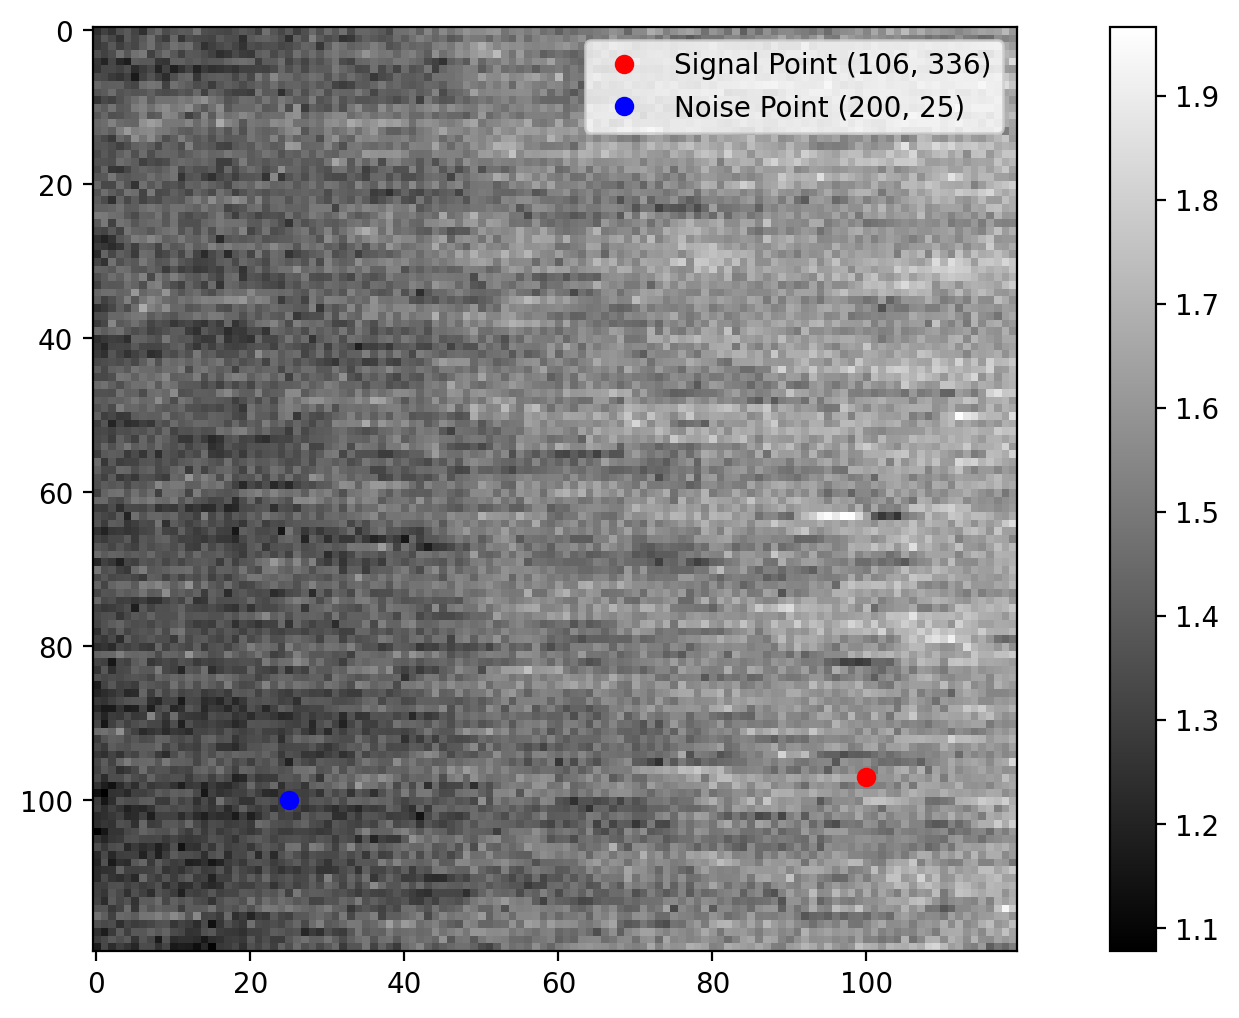

Text(0.5, 1.0, 'Spectra at Selected Points')

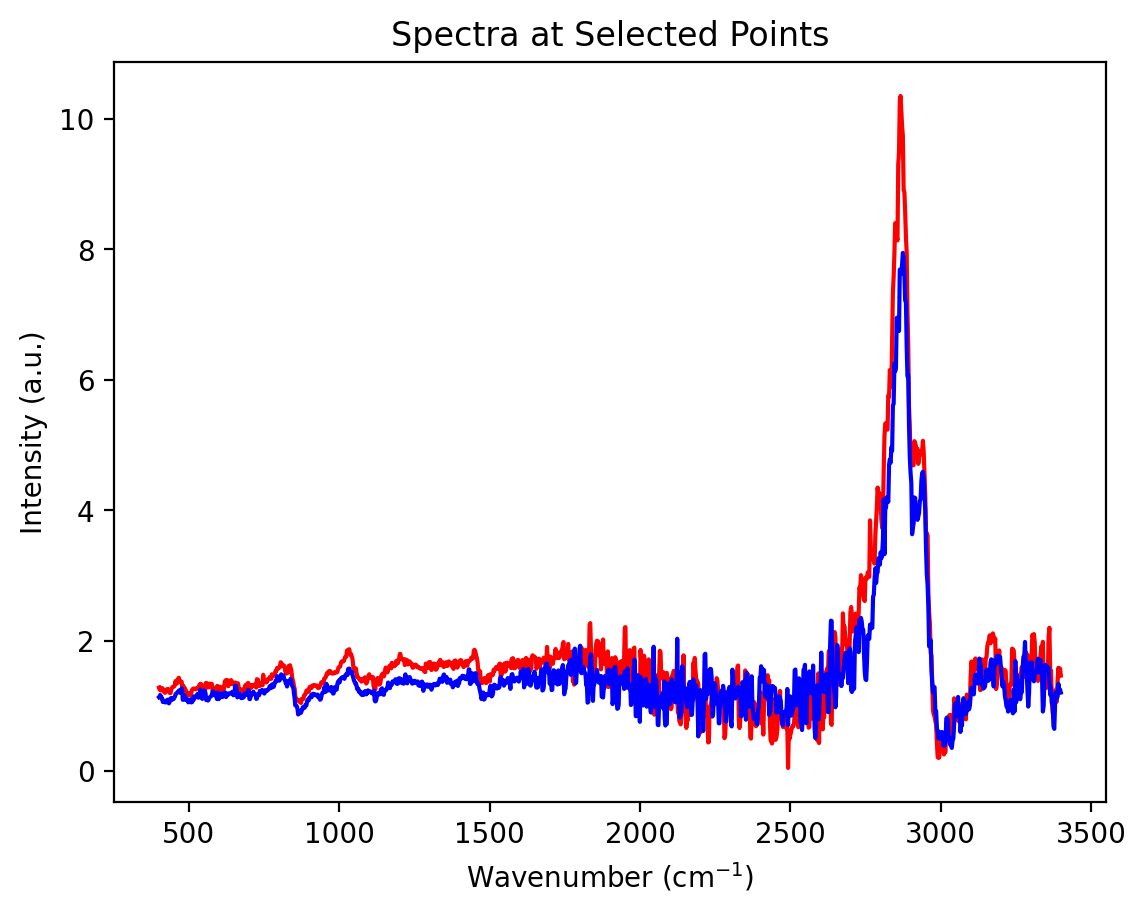

In [12]:
plt.figure(figsize=(12, 6))
plt.imshow(ratio_selected[:,:,signature_index], cmap='gray')
plt.plot(point_signal[1], point_signal[0], 'ro', label='Signal Point (106, 336)')
plt.plot(point_noise[1], point_noise[0], 'bo', label='Noise Point (200, 25)')
plt.legend()
plt.colorbar()
plt.show()

plt.figure()
plt.plot(wn_selected, ratio_selected[point_signal[0], point_signal[1], :],color="r", label='Signal Point (106, 336)')
plt.plot(wn_selected, ratio_selected[point_noise[0], point_noise[1], :], color="b", label='Noise Point (200, 25)')
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Spectra at Selected Points')

In [13]:
print(ratio_selected.shape)
x = ratio_selected.transpose(2,0,1)
axes = 'ZYX'
print(x.shape, axes)

(120, 120, 1345)
(1345, 120, 120) ZYX


In [14]:
model = CARE(config=None, name='my_model', basedir='models')

W0000 00:00:1758520669.048900   77912 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1758520669.051118   77912 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1758520669.216688   77912 gpu_device.cc:2040] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29041 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:01:00.0, compute capability: 12.0a


Loading network weights from 'weights_best.h5'.


In [15]:
restored = model.predict(x, axes, n_tiles=(8,1,1))

I0000 00:00:1758520678.034360   79774 service.cc:158] XLA service 0x7d819c003af0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758520678.034389   79774 service.cc:166]   StreamExecutor device (0): NVIDIA GeForce RTX 5090, Compute Capability 12.0a
I0000 00:00:1758520678.053714   79774 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1758520678.096968   79774 cuda_dnn.cc:463] Loaded cuDNN version 91002
E0000 00:00:1758520683.011296   79945 slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f32[1,32,212,120,120]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[1,32,212,120,120]{4,3,2,1,0}, f32[32,32,3,3,3]{4,3,2,1,0}, f32[32]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activati

In [16]:
print(restored.shape)

(1345, 120, 120)


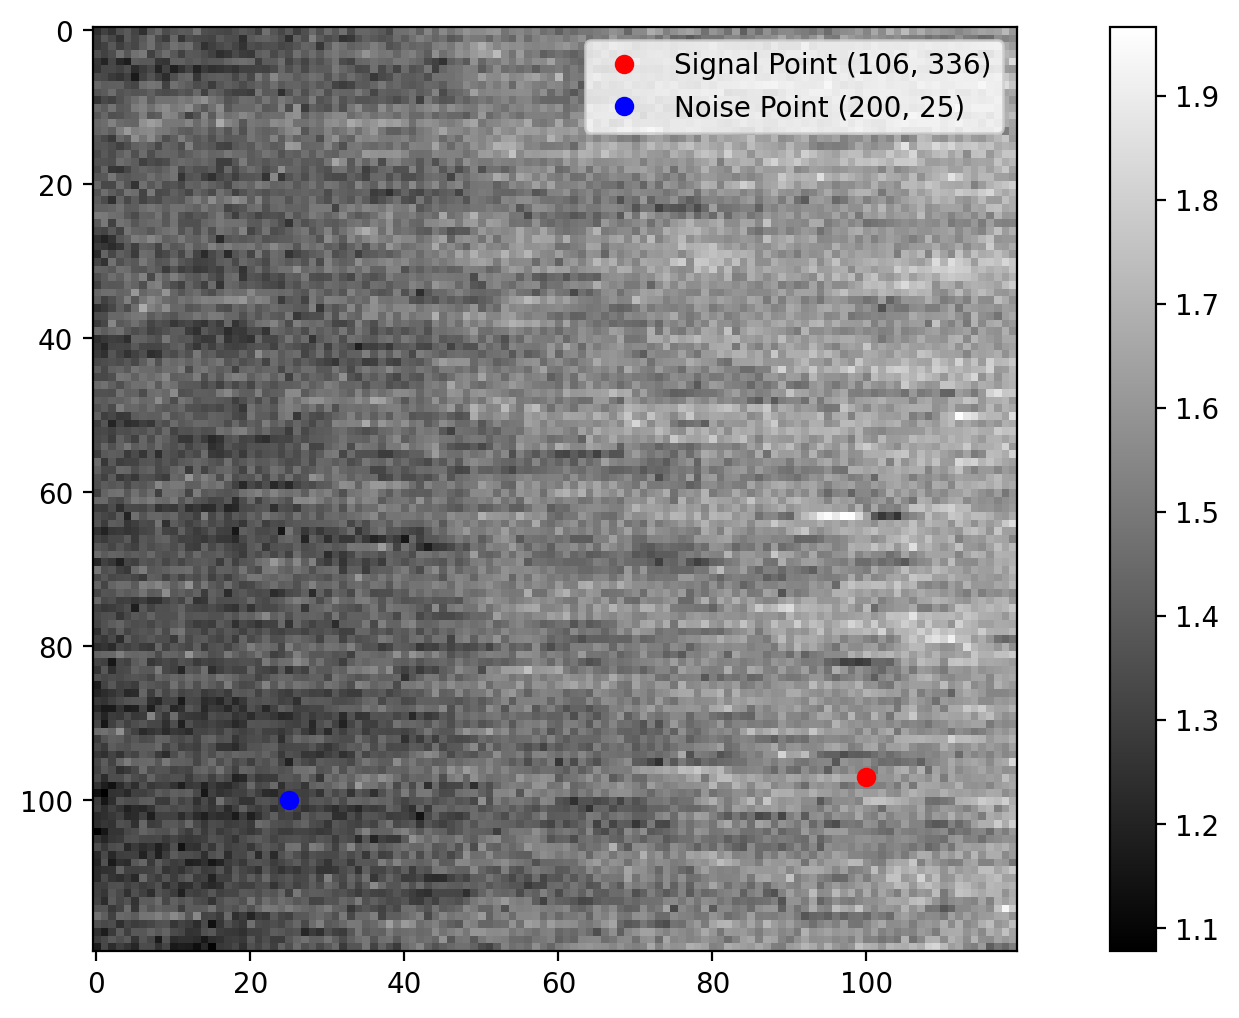

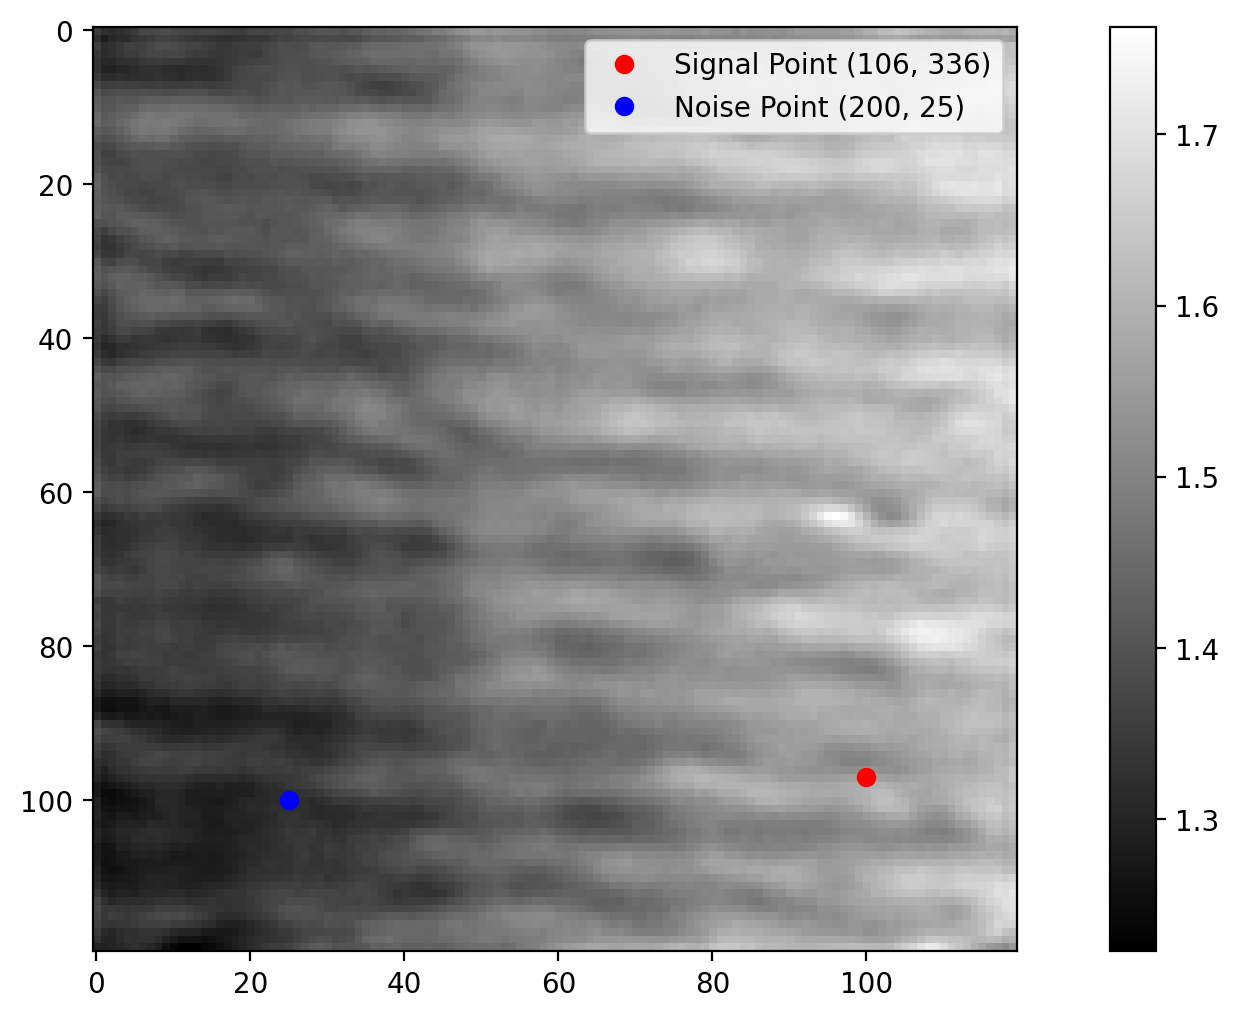

Text(0.5, 1.0, 'Spectra at Selected Points')

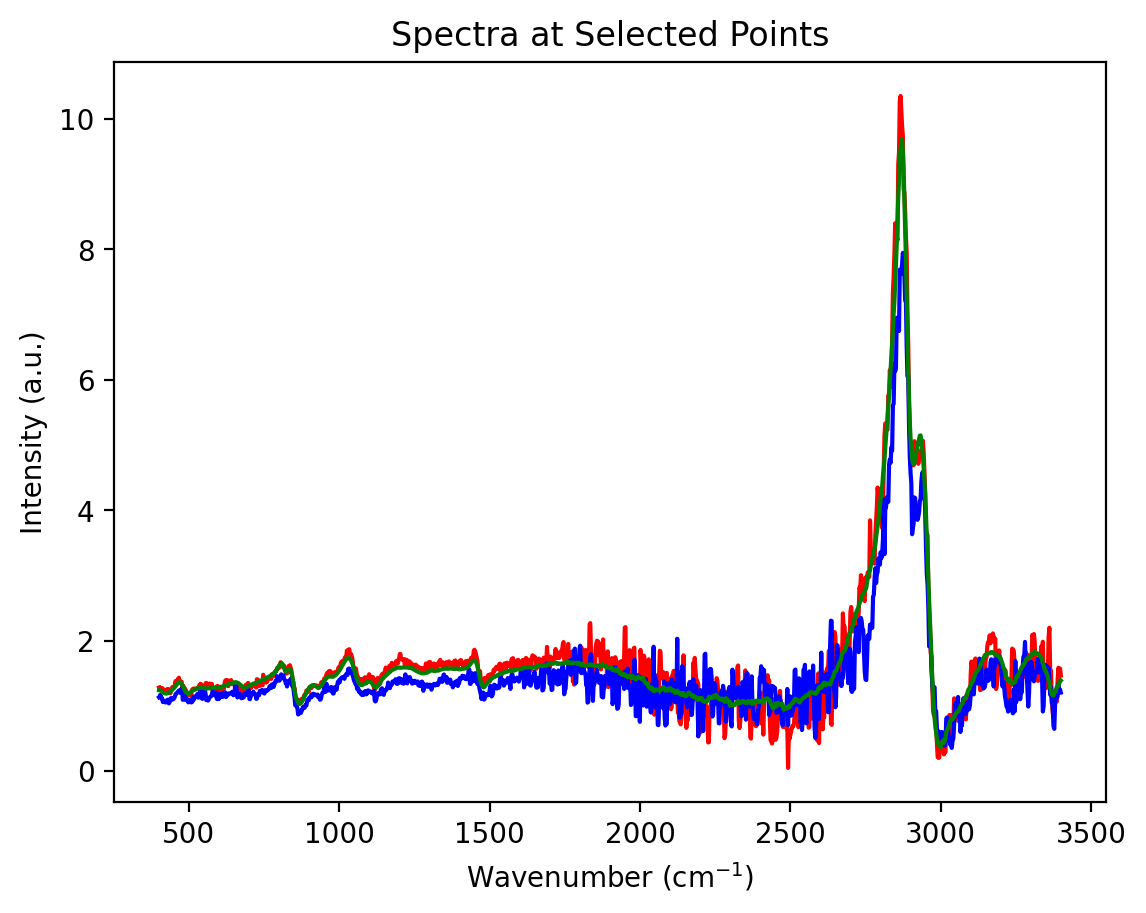

In [17]:
plt.figure(figsize=(12, 6))
plt.imshow(ratio_selected[:,:,signature_index], cmap='gray')
plt.plot(point_signal[1], point_signal[0], 'ro', label='Signal Point (106, 336)')
plt.plot(point_noise[1], point_noise[0], 'bo', label='Noise Point (200, 25)')
plt.legend()
plt.colorbar()
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(restored[signature_index,:,:,], cmap='gray')
plt.plot(point_signal[1], point_signal[0], 'ro', label='Signal Point (106, 336)')
plt.plot(point_noise[1], point_noise[0], 'bo', label='Noise Point (200, 25)')
plt.legend()
plt.colorbar()
plt.show()



plt.figure()
plt.plot(wn_selected, ratio_selected[point_signal[0], point_signal[1], :],color="r", label='Signal Point (106, 336)')
plt.plot(wn_selected, ratio_selected[point_noise[0], point_noise[1], :], color="b", label='Noise Point (100, 25)')
plt.plot(wn_selected, restored[:, point_signal[0], point_signal[1]], 'g', label='Restored Signal Point (106, 336)')
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Spectra at Selected Points')

In [18]:
np.savez('denoised_glycerol_data.npz', raw=ratio_selected, denoised=restored, wn=wn_selected)

In [12]:
print(wn)

[-456.34041022 -454.73983785 -453.13886012 ... 4739.75783381 4742.94480934
 4746.1329239 ]
